# Customer Segmentation Analysis

## Internship Project

### Submitted By:
LIPSHA GIRI

### Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [18]:
# Load dataset

df = pd.read_csv('ifood_df.csv')

# Display first 5 rows

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [19]:
# Shape

print("Dataset Shape:", df.shape)

# Information

df.info()

# Missing values

print(df.isnull().sum())

# Columns

print(df.columns)

Dataset Shape: (2205, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  


In [20]:
# Remove duplicates

df.drop_duplicates(inplace=True)

# Fill missing values

df.fillna(method='ffill', inplace=True)

print("Data Cleaning Completed")

Data Cleaning Completed


/tmp/ipykernel_9710/1583781570.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [21]:
# Statistical summary

print(df.describe())

              Income      Kidhome     Teenhome      Recency     MntWines  \
count    2021.000000  2021.000000  2021.000000  2021.000000  2021.000000   
mean    51687.258783     0.443345     0.509649    48.880752   306.492331   
std     20713.046401     0.536196     0.546393    28.950917   337.603877   
min      1730.000000     0.000000     0.000000     0.000000     0.000000   
25%     35416.000000     0.000000     0.000000    24.000000    24.000000   
50%     51412.000000     0.000000     0.000000    49.000000   178.000000   
75%     68274.000000     1.000000     1.000000    74.000000   507.000000   
max    113734.000000     2.000000     2.000000    99.000000  1493.000000   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
count  2021.000000      2021.000000      2021.000000       2021.000000   
mean     26.364671       166.059871        37.603662         27.268679   
std      39.776518       219.869126        54.892196         41.575454   
min       0.000000 

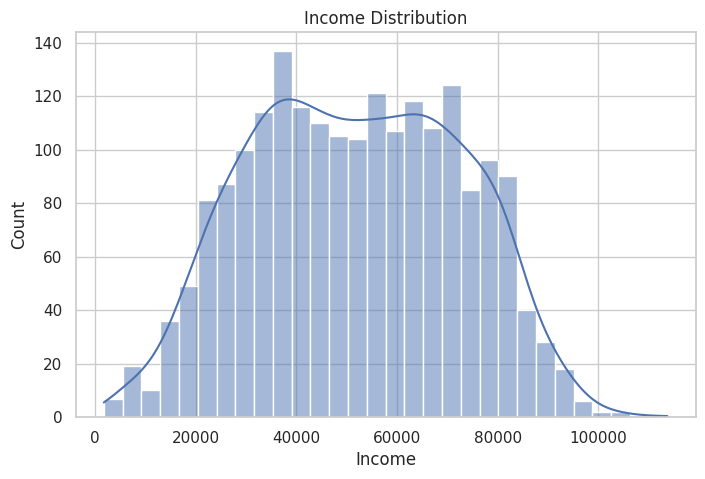

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['Income'],
             bins=30,
             kde=True)

plt.title('Income Distribution')

plt.show()

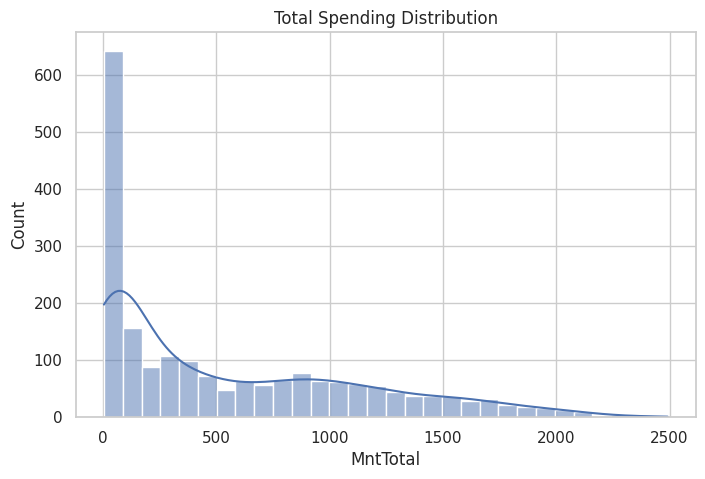

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['MntTotal'],
             bins=30,
             kde=True)

plt.title('Total Spending Distribution')

plt.show()

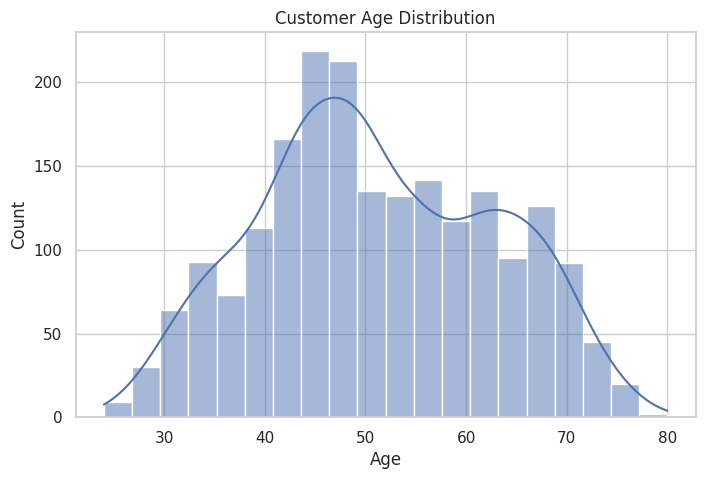

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=20,
             kde=True)

plt.title('Customer Age Distribution')

plt.show()

In [25]:
# Feature selection

X = df[['Income',
        'MntTotal',
        'NumWebPurchases',
        'NumStorePurchases']]

In [26]:
# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

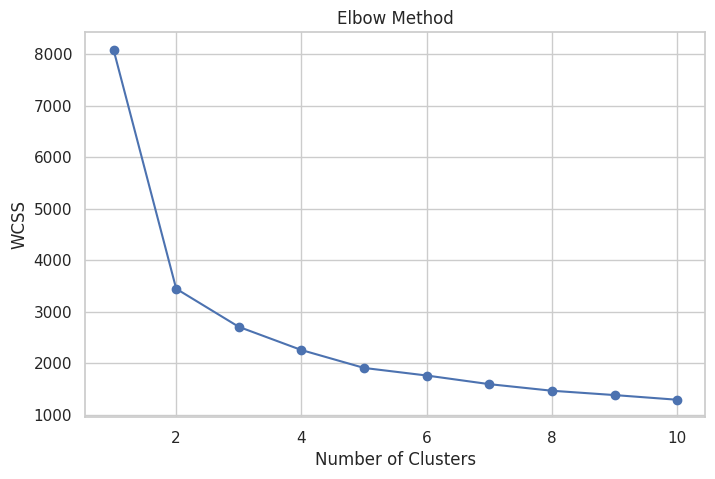

In [27]:
# Elbow Method

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [28]:
# Apply KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display rows

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,1
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,1
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,3


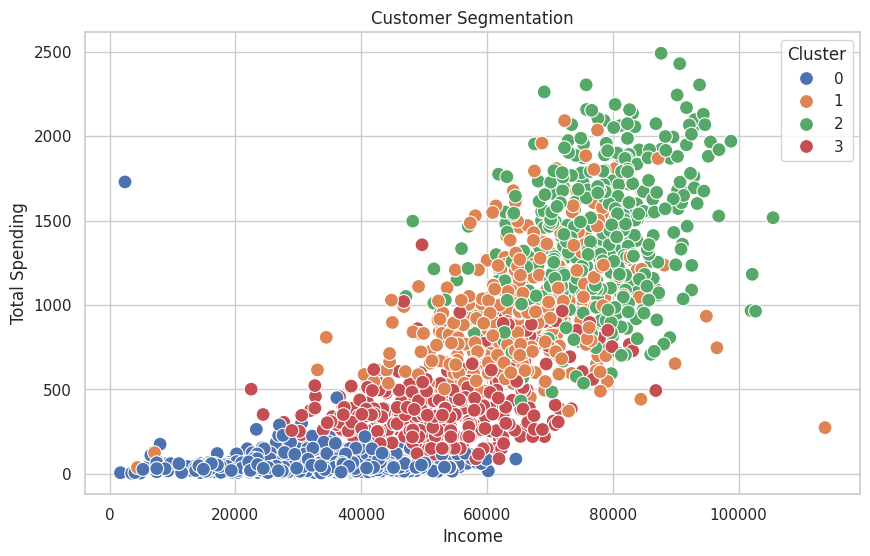

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Income'],
    y=df['MntTotal'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title('Customer Segmentation')

plt.xlabel('Income')

plt.ylabel('Total Spending')

plt.show()

In [30]:
# Cluster summary

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

               Income   Kidhome  Teenhome    Recency    MntWines  MntFruits  \
Cluster                                                                       
0        31939.842303  0.829787  0.433041  48.693367   25.712140   4.211514   
1        64389.305714  0.151429  0.762857  49.531429  571.900000  43.288571   
2        76928.353349  0.060046  0.217090  48.789838  683.362587  61.586605   
3        52605.425968  0.350797  0.735763  48.792711  234.205011  18.451025   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0              19.295369         6.016270          4.361702     13.637046   
1             216.925714        58.525714         44.045714     71.351429   
2             465.745958        88.745958         64.230947     73.466513   
3              97.034169        27.970387         19.127563     48.031891   

         ...  marital_Together  marital_Widow  education_2n Cy

## Business Insights

### Cluster 0
Customers in this segment have high income and high spending behavior. These are premium customers who contribute significantly to company revenue.

### Cluster 1
Customers with low income and low spending behavior represent budget-conscious customers.

### Cluster 2
Customers with moderate income and moderate spending show stable purchasing patterns and potential for future growth.

### Cluster 3
Customers with high income but lower spending may require personalized offers and targeted promotions to improve engagement.

## Recommendations

### 1. Loyalty Programs
Provide exclusive rewards and membership benefits for premium customers.

### 2. Personalized Marketing
Target customers with customized product recommendations based on purchasing behavior.

### 3. Promotional Campaigns
Offer discounts and deals to low-spending customers to increase engagement.

### 4. Improve Customer Retention
Focus on customer satisfaction through personalized communication and offers.

### 5. Data-Driven Strategies
Use customer segmentation insights to improve marketing and sales strategies.

## Conclusion

The Customer Segmentation Analysis project successfully grouped customers into different segments using the K-Means clustering algorithm. By analyzing customer income, purchasing behavior, and spending patterns, meaningful customer groups were identified.

The project provided valuable insights that can help businesses improve customer targeting, marketing strategies, and customer retention. Additionally, this project enhanced practical skills in data cleaning, exploratory data analysis, clustering algorithms, and data visualization using Python.